In [7]:
import numpy as np
from behavior_models import models
from one.api import ONE
from brainbox.io.one import SpikeSortingLoader, SessionLoader
import pandas as pd


In [10]:
one = ONE(base_url="https://openalyx.internationalbrainlab.org", password="international")
eids_df = pd.read_csv('D:\personal\phD\code\information-decomposition\ibl-partial-info-decomp\data\processed\eids_to_analyse.csv')
eids = eids_df.eid
sl = SessionLoader(one=one, eid=eids[0])
sl.load_trials()



In [13]:
my_model = models.ActionKernel(path_to_results="results_behavioral", session_uuids=eids[0], df_trials=sl.trials, single_zeta=False)

In [14]:
my_model.load_or_train(remove_old=False, adaptive=True)

2024-09-18 13:52:03 INFO     base_models.py:109  Launching MCMC procedure with 4 chains, 5000 max steps and [0.05 0.04 0.04 0.02 0.02] std_RW. Early stopping is activated
2024-09-18 13:52:03 INFO     base_models.py:119  with adaptive MCMC...
2024-09-18 13:52:03 INFO     base_models.py:121  initial point for MCMC is [[0.5    0.5    0.5    0.25   0.25  ]
 [0.75   0.25   0.75   0.125  0.375 ]
 [0.25   0.75   0.25   0.375  0.125 ]
 [0.375  0.375  0.625  0.0625 0.4375]]


 10%|█         | 500/5000 [01:39<15:43,  4.77it/s]

2024-09-18 13:53:43 INFO     base_models.py:165  Adaptive MCMC starting...


 12%|█▏        | 600/5000 [01:59<14:54,  4.92it/s]

2024-09-18 13:54:03 INFO     base_models.py:189  acceptance is 0.18333333333333335


...

 20%|██        | 1000/5000 [03:26<15:03,  4.43it/s]

2024-09-18 13:55:30 INFO     base_models.py:189  acceptance is 0.1955


 20%|██        | 1001/5000 [03:26<14:48,  4.50it/s]

2024-09-18 13:55:30 INFO     base_models.py:159  Early stopping criteria was validated at step 1001. R values are: [1.00109675 1.02546045 1.08827535 1.01943613 1.07052774]


2024-09-18 13:55:30 INFO     base_models.py:194  final posterior_mean is [0.12455651 0.07547925 0.05432001 0.09212725 0.01895787]
2024-09-18 13:55:30 INFO     base_models.py:203  acceptance ratio is of 0.1953046953046953. Careful, this ratio should be close to 0.234. If not, change the standard deviation of the random walk
2024-09-18 13:55:30 INFO     base_models.py:312  results of inference SAVED in results_behavioral\model_actKernel\train_b52182e7.pkl


In [15]:

# predict trials and eventually join in the original dataframe
df_prior = my_model.predict_trials()
df_trials = sl.trials.join(df_prior, how='left')

In [23]:
action_kernel_prior = df_trials['prior']


In [19]:
true_block_prior = df_trials['probabilityLeft']

In [20]:
from matplotlib import pyplot as plt

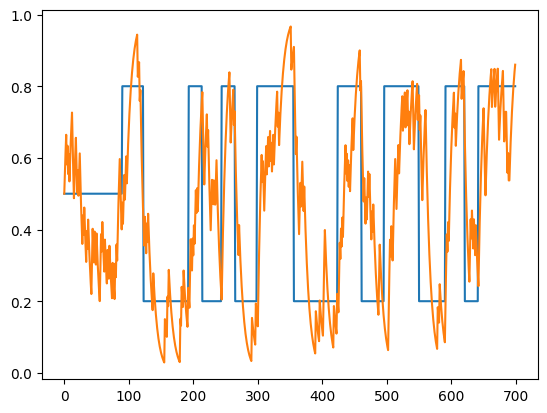

In [24]:
plt.plot(true_block_prior)
plt.plot(action_kernel_prior)